# Evidential Deep Learning - Showcase on MNIST

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Load and prepare MNIST dataset

In [3]:
MNIST_MEAN, MNIST_STD = 0.13, 0.31
NUM_CLASSES = 10
transform = T.Compose([T.ToTensor(), T.Normalize(MNIST_MEAN, MNIST_STD)])

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

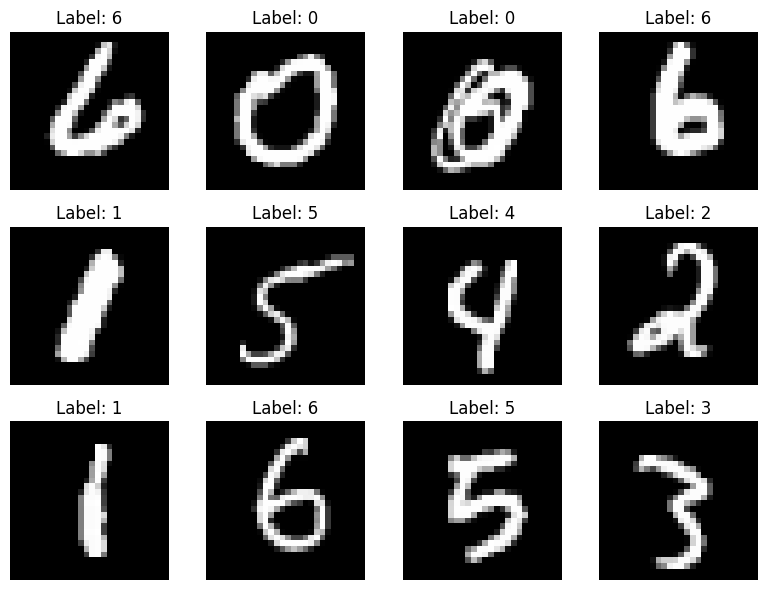

In [4]:
def show_images(images, labels, predictions=None, n_cols=4):
    n_images = len(images)
    n_rows = (n_images + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2 * n_rows))
    axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]

    for i, (image, label) in enumerate(zip(images, labels)):
        axes[i].imshow(image.reshape(28, 28), cmap="gray")
        
        if predictions is not None:
            pred = predictions[i]
            color = "green" if pred == label else "red"
            axes[i].set_title(f"True: {label.item()}\nPred: {pred.item()}", color=color)
        else:
            axes[i].set_title(f"Label: {label.item()}")
        
        axes[i].axis("off")

    # Hide unused subplots
    for i in range(n_images, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    return fig


images, labels = next(iter(train_loader))
show_images(images[:12], labels[:12]);

## Traditional CNN

Let's first train a tiny CNN in a traditional manner.

In [5]:
class TinyCnn(nn.Module):
    def __init__(self):
        super(TinyCnn, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.flatten(start_dim=1)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [6]:
model = TinyCnn()
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 3
for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    progress_bar = tqdm(
        train_loader,
        total=len(train_loader),
        desc=f"Epoch {epoch + 1}/{num_epochs}",
        postfix={"loss": 0.0},
        unit="batch",
    )

    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_loss = loss.item()
        running_loss += batch_loss
        progress_bar.set_postfix({"loss": running_loss / (progress_bar.n + 1)})

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        progress_bar = tqdm(
            test_loader,
            total=len(test_loader),
            desc=f"Validation Epoch {epoch + 1}/{num_epochs}",
            unit="batch",
        )
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Epoch 1/3: 100%|██████████| 40/40 [00:00<00:00, 41.58batch/s]


Validation Accuracy: 97.73%


Validation Epoch 2/3: 100%|██████████| 40/40 [00:00<00:00, 47.80batch/s]


Validation Accuracy: 98.30%


Validation Epoch 3/3: 100%|██████████| 40/40 [00:00<00:00, 49.73batch/s]

Validation Accuracy: 98.72%


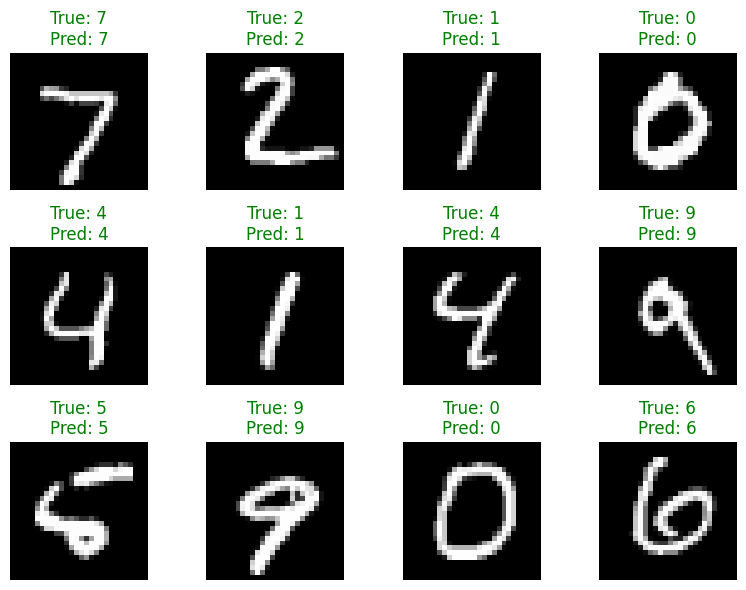

In [7]:
dataiter = iter(test_loader)
images, y = next(dataiter)
images, y = images.to(device), y.to(device)

with torch.no_grad():
    logits = model(images)
    _, preds = torch.max(logits, 1)

show_images(images.cpu().numpy()[:12], y.cpu().numpy()[:12], preds.cpu().numpy()[:12]);

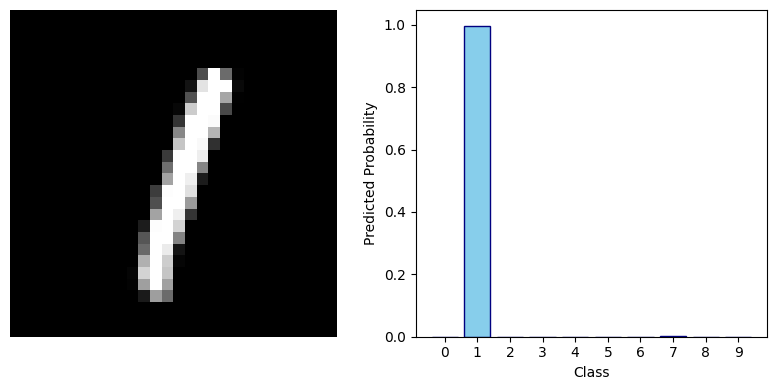

In [8]:
def plot_probs(probs, img):
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    axs[0].imshow(img.reshape(28, 28), cmap="gray")
    axs[0].axis("off")

    axs[1].bar(range(len(probs)), probs, color='skyblue', edgecolor='navy')
    axs[1].set_xticks(range(len(probs)))
    axs[1].set_xlabel("Class")
    axs[1].set_ylabel("Predicted Probability")
    fig.tight_layout()
    return fig, axs

image = images[5]
probs = F.softmax(logits[5], dim=0)
fig, axs = plot_probs(probs, image)

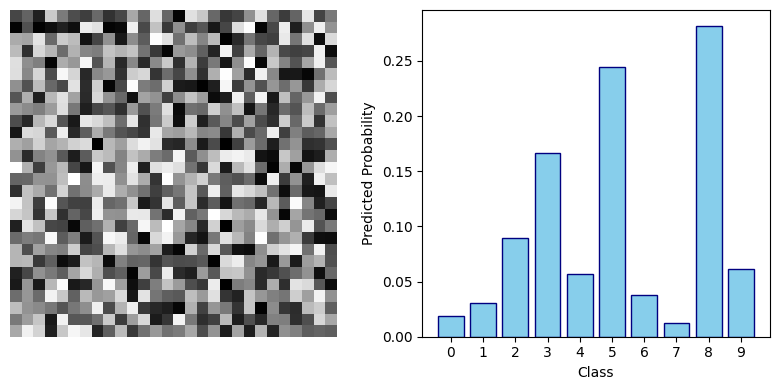

In [9]:
noise_image = torch.rand_like(image)
logits = model(noise_image.unsqueeze(0)).detach()
probs = F.softmax(logits[0], dim=0)
fig, axs = plot_probs(probs, noise_image)

## Use EDL

In [10]:
def mse_dirichlet(alpha, y):
    S = torch.sum(alpha, dim=1, keepdim=True)
    p = alpha / S
    t1 = (y - p).pow(2).sum(-1)
    t2 = ((p * (1 - p)) / (S + 1)).sum(-1)
    return torch.mean(t1 + t2)


def kl_dirichlet(alpha, y):
    # suppress the evidence of non-target classes
    alpha = y + (1 - y) * alpha
    beta = torch.ones_like(alpha)

    # kl divergence based on https://statproofbook.github.io/P/dir-kl.html
    sum_alpha = alpha.sum(-1)
    sum_beta = beta.sum(-1)

    t1 = sum_alpha.lgamma() - sum_beta.lgamma()
    t2 = (alpha.lgamma() - beta.lgamma()).sum(-1)
    t3 = alpha - beta
    t4 = alpha.digamma() - sum_alpha.digamma().unsqueeze(-1)

    kl = t1 - t2 + (t3 * t4).sum(-1)
    return kl.mean()


def edl_loss(logits, labels, epoch, num_epochs):
    y = F.one_hot(labels, num_classes=NUM_CLASSES).float()

    evidence = F.softplus(logits)
    alpha = evidence + 1

    mse = mse_dirichlet(alpha, y)
    kl = kl_dirichlet(alpha, y)

    annealing_coef = min(1.0, epoch / num_epochs)

    return mse + annealing_coef * kl, mse.detach(), kl.detach()

In [11]:
model = TinyCnn()
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 3
for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    progress_bar = tqdm(
        train_loader,
        total=len(train_loader),
        desc=f"Epoch {epoch + 1}/{num_epochs}",
        postfix={"loss": 0.0},
        unit="batch",
    )

    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss, _, _ = edl_loss(outputs, labels, epoch, num_epochs)
        loss.backward()
        optimizer.step()

        batch_loss = loss.item()
        running_loss += batch_loss
        progress_bar.set_postfix({"loss": running_loss / (progress_bar.n + 1)})

    model.eval()
    correct = 0
    total = 0
    uncertainty = 0.0
    with torch.no_grad():
        progress_bar = tqdm(
            test_loader,
            total=len(test_loader),
            desc=f"Validation Epoch {epoch + 1}/{num_epochs}",
            unit="batch",
        )
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            evidence = F.softplus(outputs)
            alpha = evidence + 1
            S = torch.sum(alpha, dim=1, keepdim=True)
            uncertainty += torch.sum(NUM_CLASSES / S).item()

    accuracy = 100 * correct / total
    print(f"Validation Accuracy: {accuracy:.2f}%")
    print(f"Average Uncertainty: {uncertainty / total:.4f}")

Validation Epoch 1/3: 100%|██████████| 40/40 [00:00<00:00, 45.94batch/s]


Validation Accuracy: 93.51%
Average Uncertainty: 0.1621


Validation Epoch 2/3: 100%|██████████| 40/40 [00:00<00:00, 48.09batch/s]


Validation Accuracy: 95.56%
Average Uncertainty: 0.2735


Validation Epoch 3/3: 100%|██████████| 40/40 [00:00<00:00, 50.61batch/s]

Validation Accuracy: 96.95%
Average Uncertainty: 0.2565


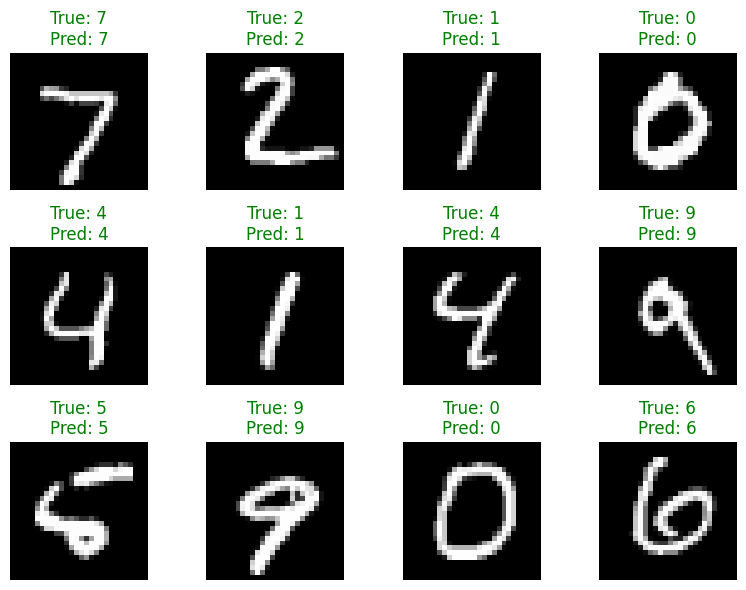

In [12]:
dataiter = iter(test_loader)
images, y = next(dataiter)
images, y = images.to(device), y.to(device)
logits = model(images)
_, preds = torch.max(logits, 1)
show_images(images.cpu().numpy()[:12], y.cpu().numpy()[:12], preds.cpu().numpy()[:12]);

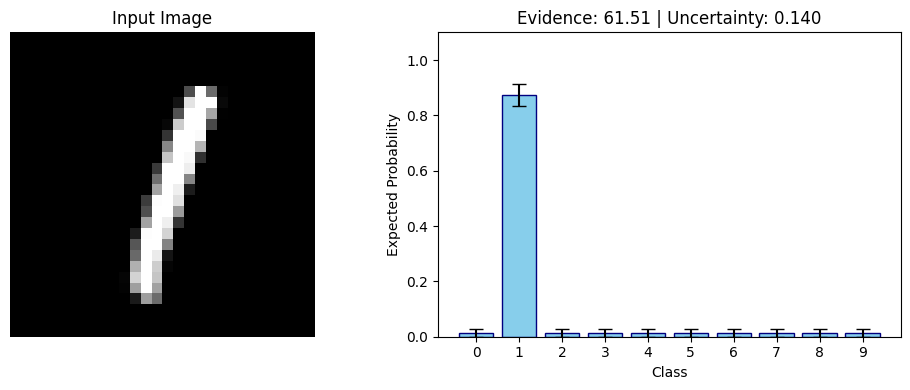

In [17]:
def plot_probs(outputs, img):
    # 1. Convert raw outputs to Dirichlet parameters
    evidence = F.softplus(outputs)
    alpha = evidence + 1
    S = torch.sum(alpha, dim=0, keepdim=True)
    
    # 2. Compute Mean (Expected Probabilities)
    probs = (alpha / S).squeeze().detach().cpu().numpy()
    
    # 3. Compute Variance and Standard Deviation for error bars
    # Var = [alpha * (S - alpha)] / [S^2 * (S + 1)]
    variance = (alpha * (S - alpha)) / (S**2 * (S + 1))
    std_dev = torch.sqrt(variance).squeeze().detach().cpu().numpy()
    
    # 4. Plotting
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    
    axs[0].imshow(img.reshape(28, 28), cmap="gray")
    axs[0].set_title("Input Image")
    axs[0].axis("off")

    classes = range(len(probs))
    axs[1].bar(classes, probs, yerr=std_dev, capsize=5, color='skyblue', edgecolor='navy')
    axs[1].set_xticks(classes)
    axs[1].set_xlabel("Class")
    axs[1].set_ylabel("Expected Probability")
    axs[1].set_ylim(0, 1.1) # Extra space for error bars
    total_evidence = S.item() - len(probs) 
    axs[1].set_title(f"Evidence: {total_evidence:.2f} | Uncertainty: {len(probs)/S.item():.3f}")
    
    fig.tight_layout()
    return fig, axs

image = images[5]
outputs = logits[5]
fig, axs = plot_probs(outputs, image)

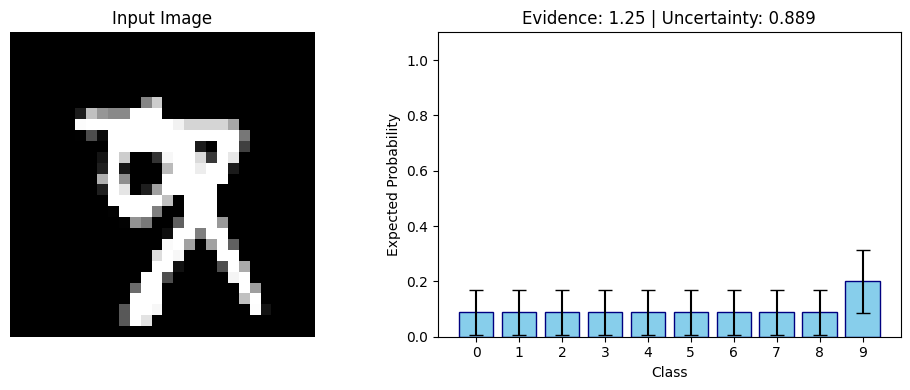

In [29]:
mix_image = torch.clamp((images[0] + images[7]) / 2, 0, 1)
outputs = model(mix_image.unsqueeze(0)).detach()[0]
fig, axs = plot_probs(outputs, mix_image)